In [5]:
import pandas as pd

In [7]:
# 1. Load the dataset
df = pd.read_csv("/content/Lending Club Loan.csv")

In [8]:
# 2. Drop the messy text and date columns
cols_to_drop = ['emp_title', 'title', 'issue_d', 'earliest_cr_line', 'address']
df_cleaned = df.drop(columns=cols_to_drop)

In [9]:
# 3. Convert the 'term' column to integers
# This takes " 36 months", splits it by the space, and keeps the number 36
df_cleaned['term'] = df_cleaned['term'].apply(lambda x: int(str(x).strip().split()[0]))

In [10]:
# 4. Map the target variable for Logistic Regression
# We turn the text outcomes into binary 1 (Good Loan) and 0 (Bad Loan)
df_cleaned['loan_status'] = df_cleaned['loan_status'].map({'Fully Paid': 1, 'Charged Off': 0})

In [11]:
# 5. Apply One-Hot Encoding
# drop_first=True helps prevent "multicollinearity" which can confuse linear regression models
df_cleaned = pd.get_dummies(df_cleaned, columns=['home_ownership', 'verification_status', 'purpose', 'grade', 'sub_grade', 'initial_list_status', 'application_type'], drop_first=True)

In [12]:
# Check the new shape and structure
print("Cleaned Data Shape:", df_cleaned.shape)
print(df_cleaned.head())

Cleaned Data Shape: (27069, 78)
   loan_amnt  term  int_rate  installment emp_length  annual_inc  loan_status  \
0      10000    36     11.44       329.48  10+ years    117000.0            1   
1       8000    36     11.99       265.68    4 years     65000.0            1   
2      15600    36     10.49       506.97   < 1 year     43057.0            1   
3       7200    36      6.49       220.65    6 years     54000.0            1   
4      24375    60     17.27       609.33    9 years     55000.0            0   

     dti  open_acc  pub_rec  ...  sub_grade_F4  sub_grade_F5  sub_grade_G1  \
0  26.24        16        0  ...         False         False         False   
1  22.05        17        0  ...         False         False         False   
2  12.79        13        0  ...         False         False         False   
3   2.60         6        0  ...         False         False         False   
4  33.95        13        0  ...         False         False         False   

   sub_grade

In [13]:
df_cleaned

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,loan_status,dti,open_acc,pub_rec,...,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000,36,11.44,329.48,10+ years,117000.0,1,26.24,16,0,...,False,False,False,False,False,False,False,True,True,False
1,8000,36,11.99,265.68,4 years,65000.0,1,22.05,17,0,...,False,False,False,False,False,False,False,False,True,False
2,15600,36,10.49,506.97,< 1 year,43057.0,1,12.79,13,0,...,False,False,False,False,False,False,False,False,True,False
3,7200,36,6.49,220.65,6 years,54000.0,1,2.60,6,0,...,False,False,False,False,False,False,False,False,True,False
4,24375,60,17.27,609.33,9 years,55000.0,0,33.95,13,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,25000,60,18.99,648.38,7 years,50000.0,1,36.73,10,0,...,False,False,False,False,False,False,False,True,True,False
27065,24000,60,11.99,533.75,10+ years,60000.0,0,21.52,13,0,...,False,False,False,False,False,False,False,True,True,False
27066,20000,60,21.18,543.10,10+ years,75000.0,1,15.23,12,1,...,False,False,False,False,False,False,False,True,True,False
27067,15000,60,23.40,426.32,2 years,72000.0,1,28.07,22,0,...,False,False,False,False,False,False,False,False,True,False


In [15]:
df = df_cleaned.copy()

# Display the first 5 rows of df1 to confirm the renaming
display(df.head())

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,loan_status,dti,open_acc,pub_rec,...,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000,36,11.44,329.48,10+ years,117000.0,1,26.24,16,0,...,False,False,False,False,False,False,False,True,True,False
1,8000,36,11.99,265.68,4 years,65000.0,1,22.05,17,0,...,False,False,False,False,False,False,False,False,True,False
2,15600,36,10.49,506.97,< 1 year,43057.0,1,12.79,13,0,...,False,False,False,False,False,False,False,False,True,False
3,7200,36,6.49,220.65,6 years,54000.0,1,2.60,6,0,...,False,False,False,False,False,False,False,False,True,False
4,24375,60,17.27,609.33,9 years,55000.0,0,33.95,13,0,...,False,False,False,False,False,False,False,False,True,False


In [16]:
df

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,loan_status,dti,open_acc,pub_rec,...,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000,36,11.44,329.48,10+ years,117000.0,1,26.24,16,0,...,False,False,False,False,False,False,False,True,True,False
1,8000,36,11.99,265.68,4 years,65000.0,1,22.05,17,0,...,False,False,False,False,False,False,False,False,True,False
2,15600,36,10.49,506.97,< 1 year,43057.0,1,12.79,13,0,...,False,False,False,False,False,False,False,False,True,False
3,7200,36,6.49,220.65,6 years,54000.0,1,2.60,6,0,...,False,False,False,False,False,False,False,False,True,False
4,24375,60,17.27,609.33,9 years,55000.0,0,33.95,13,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,25000,60,18.99,648.38,7 years,50000.0,1,36.73,10,0,...,False,False,False,False,False,False,False,True,True,False
27065,24000,60,11.99,533.75,10+ years,60000.0,0,21.52,13,0,...,False,False,False,False,False,False,False,True,True,False
27066,20000,60,21.18,543.10,10+ years,75000.0,1,15.23,12,1,...,False,False,False,False,False,False,False,True,True,False
27067,15000,60,23.40,426.32,2 years,72000.0,1,28.07,22,0,...,False,False,False,False,False,False,False,False,True,False


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np

In [18]:
df = df.dropna()

In [19]:
df

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,loan_status,dti,open_acc,pub_rec,...,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000,36,11.44,329.48,10+ years,117000.0,1,26.24,16,0,...,False,False,False,False,False,False,False,True,True,False
1,8000,36,11.99,265.68,4 years,65000.0,1,22.05,17,0,...,False,False,False,False,False,False,False,False,True,False
2,15600,36,10.49,506.97,< 1 year,43057.0,1,12.79,13,0,...,False,False,False,False,False,False,False,False,True,False
3,7200,36,6.49,220.65,6 years,54000.0,1,2.60,6,0,...,False,False,False,False,False,False,False,False,True,False
4,24375,60,17.27,609.33,9 years,55000.0,0,33.95,13,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27063,17000,36,12.39,567.82,4 years,78000.0,1,20.50,11,1,...,False,False,False,False,False,False,False,False,True,False
27064,25000,60,18.99,648.38,7 years,50000.0,1,36.73,10,0,...,False,False,False,False,False,False,False,True,True,False
27065,24000,60,11.99,533.75,10+ years,60000.0,0,21.52,13,0,...,False,False,False,False,False,False,False,True,True,False
27066,20000,60,21.18,543.10,10+ years,75000.0,1,15.23,12,1,...,False,False,False,False,False,False,False,True,True,False


In [26]:
# 3. Linear Regression: Predicting Interest Rate (int_rate)

# Re-initialize df from df_cleaned to ensure it's not empty due to previous operations
df = df_cleaned.copy()

# Convert 'emp_length' to numerical values
# This should handle cases like '10+ years', '< 1 year', and 'n/a'
emp_length_mapping = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

# Using .loc to avoid SettingWithCopyWarning and apply mapping
df.loc[:, 'emp_length'] = df['emp_length'].map(emp_length_mapping)

# Fill any remaining NaNs in 'emp_length' (which would be from values not in the mapping)
# with 0. This prevents dropping rows that have valid data in other columns.
df.loc[:, 'emp_length'] = df['emp_length'].fillna(0)

# Ensure 'emp_length' is of numeric type after mapping and filling NaNs
df.loc[:, 'emp_length'] = pd.to_numeric(df['emp_length'])

# Drop rows with any remaining NaNs in the feature columns, if any were introduced or missed
df.dropna(inplace=True) # This is a general dropna to handle any other NaNs in the dataset before model training

X_lin = df.drop(columns=['int_rate', 'loan_status']) # Features
y_lin = df['int_rate']                               # Target (Continuous)

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train_lin, y_train_lin)
lin_preds = linear_model.predict(X_test_lin)
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test_lin, lin_preds)):.2f}")

Linear Regression RMSE: 0.80


/tmp/ipykernel_1648/769729229.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[:, 'emp_length'] = df['emp_length'].fillna(0)


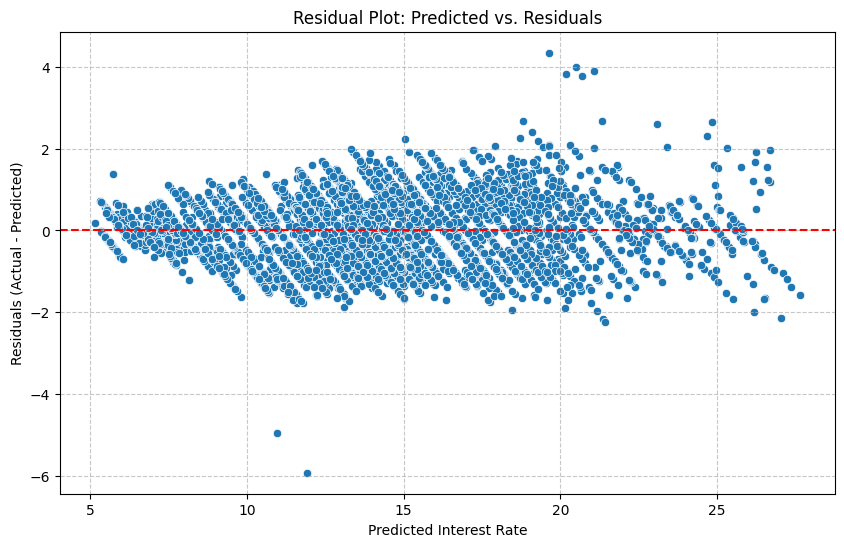

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test_lin - lin_preds

# Create a scatter plot of predicted values vs. residuals
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=lin_preds, y=residuals)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.title('Residual Plot: Predicted vs. Residuals')
plt.xlabel('Predicted Interest Rate')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 4. Logistic Regression: Predicting Default Risk (loan_status)

In [28]:
# Define features (X_log) and target (y_log) for Logistic Regression
# Drop 'int_rate' as it's not the target here, and 'loan_status' is the target
X_log = df.drop(columns=['loan_status', 'int_rate']) # Features
y_log = df['loan_status']                             # Target (Binary: 1=Paid, 0=Charged Off)

# Split the data into training and testing sets
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
logistic_model.fit(X_train_log, y_train_log)

# Make predictions on the test set
log_preds = logistic_model.predict(X_test_log)

# Evaluate the model
accuracy = accuracy_score(y_test_log, log_preds)
print(f"Logistic Regression Accuracy: {accuracy:.2f}")

Logistic Regression Accuracy: 0.80


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 5. Scaling Data and Retraining Logistic Regression Model

In [29]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_log_scaled = scaler.fit_transform(X_train_log)
X_test_log_scaled = scaler.transform(X_test_log)

print("Data scaled successfully.")

Data scaled successfully.


In [30]:
# Retrain the Logistic Regression model with scaled data
logistic_model_scaled = LogisticRegression(max_iter=1000) # Keep max_iter
logistic_model_scaled.fit(X_train_log_scaled, y_train_log)

# Make predictions on the scaled test set
log_preds_scaled = logistic_model_scaled.predict(X_test_log_scaled)

# Evaluate the model with scaled data
accuracy_scaled = accuracy_score(y_test_log, log_preds_scaled)
print(f"Logistic Regression Accuracy (Scaled Data): {accuracy_scaled:.2f}")

Logistic Regression Accuracy (Scaled Data): 0.80


### 6. Plotting ROC Curve for Logistic Regression Model

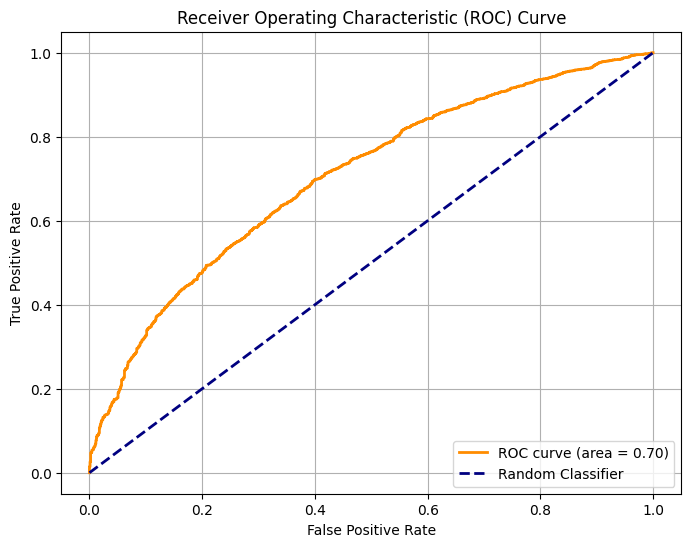

Area Under the Curve (AUC): 0.70


In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions for the positive class (1)
# We use the model trained on scaled data, as it's the more robust version.
log_probs = logistic_model_scaled.predict_proba(X_test_log_scaled)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test_log, log_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.2f}")

In [32]:
import joblib

# Save the trained models and scaler already existing in your notebook memory
joblib.dump(linear_model, 'linear_model.pkl')
joblib.dump(logistic_model_scaled, 'logistic_model_scaled.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save a reference row (median values of the training set)
# This allows the Streamlit app to maintain the exact 78-column shape expected by the model
reference_row = X_train_lin.median().to_frame().T
joblib.dump(reference_row, 'reference_row.pkl')

print("Models, scaler, and reference row saved successfully!")

Models, scaler, and reference row saved successfully!


In [33]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load the saved models and reference data
linear_model = joblib.load('linear_model.pkl')
logistic_model_scaled = joblib.load('logistic_model_scaled.pkl')
scaler = joblib.load('scaler.pkl')
reference_row = joblib.load('reference_row.pkl')

st.title("ABC Ltd Credit Prediction Tool")
st.markdown("Assess optimal interest rates and default probabilities for new loan applications.")

# Sidebar inputs for the Manager
st.sidebar.header("Applicant Profile")
loan_amnt = st.sidebar.number_input("Requested Loan Amount ($)", min_value=1000, value=15000)
term = st.sidebar.selectbox("Loan Term (Months)", [36, 60])
annual_inc = st.sidebar.number_input("Annual Income ($)", min_value=10000, value=75000)
dti = st.sidebar.slider("Debt-to-Income Ratio (DTI %)", 0.0, 50.0, 15.0)

if st.button("Generate AI Prediction"):
    # Copy the reference row to maintain the 78-column structure
    input_df = reference_row.copy()

    # Update with the specific inputs from the sidebar
    input_df['loan_amnt'] = loan_amnt
    input_df['term'] = term
    input_df['annual_inc'] = annual_inc
    input_df['dti'] = dti

    # 1. Linear Prediction (Interest Rate)
    predicted_rate = linear_model.predict(input_df)[0]

    # 2. Logistic Prediction (Default Risk)
    input_scaled = scaler.transform(input_df)
    # predict_proba returns [prob_0, prob_1]. Class 0 was mapped to 'Charged Off'
    default_prob = logistic_model_scaled.predict_proba(input_scaled)[0][0] * 100

    # Display the results cleanly
    col1, col2 = st.columns(2)
    col1.metric("Predicted Optimal Interest Rate", f"{predicted_rate:.2f}%")
    col2.metric("Predicted Risk of Default", f"{default_prob:.1f}%")

    st.markdown("---")
    if default_prob > 30:
        st.error("⚠️ **High Risk:** The model indicates significant default probability. Manual underwriter review is strongly recommended.")
    else:
        st.success("✅ **Acceptable Risk:** Applicant matches typical profile for expedited approval workflow.")

Writing app.py
